## 1. Setup and Installation

In [2]:
print("Installing required packages...")

!pip install -U pip setuptools wheel Cython
!pip install gensim>=4.3.2
!pip install tensorflow>=2.10.0
!pip install scikit-learn>=1.0.0
!pip install matplotlib>=3.4.0
!pip install seaborn>=0.11.0
!pip install numpy>=1.21.0
!pip install pandas>=1.3.0

print("Installation complete.")

Installing required packages...
Installation complete.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import fetch_20newsgroups
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding, Bidirectional, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from gensim.models import Word2Vec
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.19.0
GPU Available: False


## 2. Data Loading and Exploration

In [4]:
print("Loading 20 Newsgroups Dataset...\n")

categories = [
    'comp.graphics',
    'sci.med',
    'rec.sport.baseball',
    'talk.politics.misc'
]

train_data = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

test_data = fetch_20newsgroups(
    subset='test',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

texts = list(train_data.data) + list(test_data.data)
labels = [train_data.target_names[i] for i in train_data.target] + \
         [test_data.target_names[i] for i in test_data.target]

print(f"Total documents: {len(texts)}")
print(f"Number of classes: {len(categories)}")
print(f"Classes: {categories}")

Loading 20 Newsgroups Dataset...

Total documents: 3732
Number of classes: 4
Classes: ['comp.graphics', 'sci.med', 'rec.sport.baseball', 'talk.politics.misc']


In [5]:
print("Dataset Statistics:\n")

unique_labels, counts = np.unique(labels, return_counts=True)
label_dist = dict(zip(unique_labels, counts))

print("Class Distribution:")
for label, count in label_dist.items():
    print(f"  {label:25} {count:4d} ({count/len(labels)*100:.1f}%)")

text_lengths = [len(text.split()) for text in texts]
print(f"\nText Length Statistics:")
print(f"  Mean length: {np.mean(text_lengths):.1f} words")
print(f"  Median length: {np.median(text_lengths):.1f} words")
print(f"  Max length: {np.max(text_lengths)} words")
print(f"  Min length: {np.min(text_lengths)} words")

Dataset Statistics:

Class Distribution:
  comp.graphics              973 (26.1%)
  rec.sport.baseball         994 (26.6%)
  sci.med                    990 (26.5%)
  talk.politics.misc         775 (20.8%)

Text Length Statistics:
  Mean length: 196.4 words
  Median length: 80.0 words
  Max length: 9196 words
  Min length: 0 words


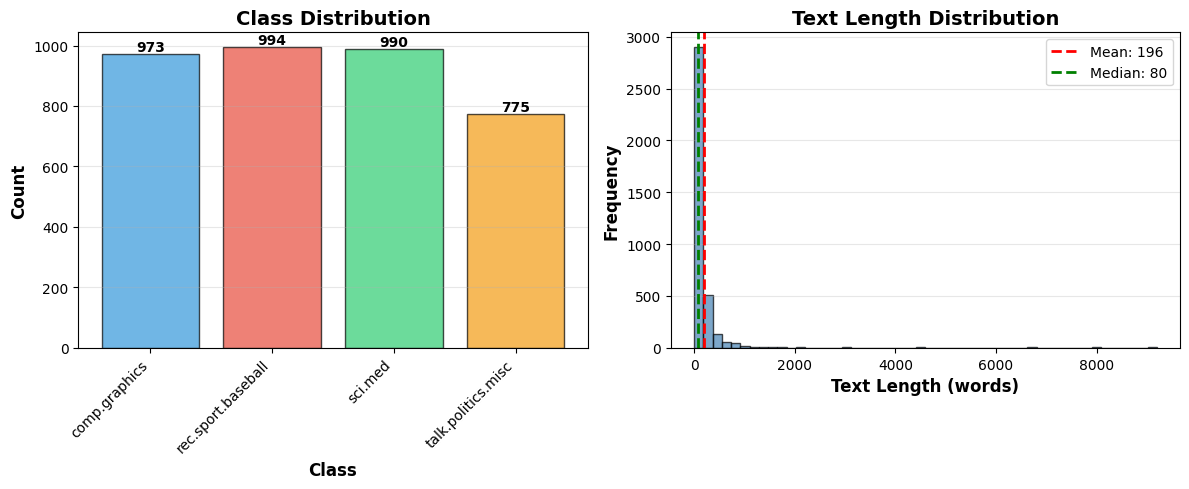

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
bars = plt.bar(label_dist.keys(), label_dist.values(), color=colors, alpha=0.7, edgecolor='black')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold')
plt.xlabel('Class', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(text_lengths, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
plt.axvline(np.mean(text_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(text_lengths):.0f}')
plt.axvline(np.median(text_lengths), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(text_lengths):.0f}')
plt.xlabel('Text Length (words)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Text Length Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
print("Sample Documents:\n")
for i in range(3):
    print(f"\nDocument {i+1}:")
    print(f"Label: {labels[i]}")
    print(f"Text: {texts[i][:300]}...")
    print("-" * 80)

Sample Documents:


Document 1:
Label: sci.med
Text: 
The speculum is the little cone that fits on the end of the otoscope.
There are also vaginal specula that females and gynecologists are
all too familiar with.
-- 
----------------------------------------------------------------------------
Gordon Banks  N3JXP      | "Skepticism is the chastity of t...
--------------------------------------------------------------------------------

Document 2:
Label: rec.sport.baseball
Text: I would like to make everyone aware that in winning the NL West the Atlanta
Braves did not lead wire-to-wire.  Through games of 4/14/93 the Houston
Astros are percentage points ahead of the "unbeatable" Braves.


Go Astros!!!!!...
--------------------------------------------------------------------------------

Document 3:
Label: sci.med
Text: 
I had a similar reaction to Chinese food but came to a completly different
conclusion. I've eaten Chinese food for ages and never had problems. I went
with some Chinese M

## 3. Data Preprocessing

In [8]:
print("Preprocessing text data...\n")

def preprocess_text(texts):
    processed = []
    for text in texts:
        text = text.lower()
        text = ' '.join(text.split())
        processed.append(text)
    return processed

texts = preprocess_text(texts)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

print(f"Preprocessed {len(texts)} documents")
print(f"Encoded {len(set(y))} classes")
print(f"Class mapping: {dict(enumerate(label_encoder.classes_))}")

Preprocessing text data...

Preprocessed 3732 documents
Encoded 4 classes
Class mapping: {0: np.str_('comp.graphics'), 1: np.str_('rec.sport.baseball'), 2: np.str_('sci.med'), 3: np.str_('talk.politics.misc')}


In [9]:
print("Creating sequences...\n")

MAX_WORDS = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Sequence shape: {X.shape}")
print(f"Using top {MAX_WORDS} words")
print(f"Sequence length: {MAX_LEN}")

Creating sequences...

Vocabulary size: 36779
Sequence shape: (3732, 100)
Using top 10000 words
Sequence length: 100


In [10]:
print("Splitting data...\n")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Train/Test ratio: {len(X_train)/len(X_test):.1f}:1")

Splitting data...

Training samples: 2985
Testing samples: 747
Train/Test ratio: 4.0:1


## 4. Model Implementation

In [11]:
def build_lstm_model(embedding_matrix=None, embedding_dim=100, lstm_units=128, num_classes=4):
    model = Sequential()

    if embedding_matrix is not None:
        vocab_size = embedding_matrix.shape[0]
        model.add(Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            input_length=MAX_LEN,
            trainable=False,
            name='pre_trained_embedding'
        ))
    else:
        vocab_size = min(len(tokenizer.word_index) + 1, MAX_WORDS)
        model.add(Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            input_length=MAX_LEN,
            name='trainable_embedding'
        ))

    model.add(SpatialDropout1D(0.2))
    model.add(Bidirectional(LSTM(lstm_units, return_sequences=True)))
    model.add(Dropout(0.3))
    model.add(Bidirectional(LSTM(lstm_units // 2)))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

print("Model building function defined")

Model building function defined


In [12]:
def train_model(model, X_train, y_train, X_test, y_test, epochs=30, batch_size=32):
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    return history

def evaluate_model(model, X_test, y_test, embedding_name):
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\nEvaluation Results - {embedding_name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    cm = confusion_matrix(y_test, y_pred)

    return {
        'accuracy': accuracy,
        'f1_score': f1,
        'y_pred': y_pred,
        'confusion_matrix': cm,
        'classification_report': classification_report(y_test, y_pred,
                                                       target_names=label_encoder.classes_,
                                                       output_dict=True)
    }

def plot_training_history(history, embedding_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'], label='Train', marker='o', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation', marker='s', linewidth=2)
    axes[0].set_title(f'Model Accuracy - {embedding_name}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'], label='Train', marker='o', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation', marker='s', linewidth=2)
    axes[1].set_title(f'Model Loss - {embedding_name}', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(cm, embedding_name):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                cbar_kws={'label': 'Count'})
    plt.title(f'Confusion Matrix - {embedding_name}', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()

print("Helper functions defined")

Helper functions defined


## 5. Experiment 1: Trainable Embeddings

In [13]:
print("\nExperiment 1: Trainable Embeddings\n")

print("Building model...")
model_trainable = build_lstm_model(
    embedding_matrix=None,
    embedding_dim=100,
    lstm_units=128,
    num_classes=len(label_encoder.classes_)
)

print("\nModel Architecture:")
model_trainable.summary()


Experiment 1: Trainable Embeddings

Building model...

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ trainable_embedding (Embedding) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
print("\nTraining model...\n")

history_trainable = train_model(
    model_trainable,
    X_train, y_train,
    X_test, y_test,
    epochs=30,
    batch_size=32
)


Training model...

Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 61s 563ms/step - accuracy: 0.3627 - loss: 1.3112 - val_accuracy: 0.6801 - val_loss: 0.8165 - learning_rate: 0.0010
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 51s 548ms/step - accuracy: 0.7520 - loss: 0.6398 - val_accuracy: 0.7764 - val_loss: 0.5760 - learning_rate: 0.0010
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 56s 595ms/step - accuracy: 0.8885 - loss: 0.3585 - val_accuracy: 0.8193 - val_loss: 0.5568 - learning_rate: 0.0010
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 52s 553ms/step - accuracy: 0.9090 - loss: 0.2668 - val_accuracy: 0.8420 - val_loss: 0.4702 - learning_rate: 0.0010
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 52s 555ms/step - accuracy: 0.9530 - loss: 0.1452 - val_accuracy: 0.8581 - val_loss: 0.4717 - learning_rate: 0.0010
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 82s 556ms/step - accuracy: 0.9624 - loss: 0.1068 - val_accuracy: 0.8032 - val_loss: 0.7563 - learning_rate: 0.0010
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy

In [15]:
results_trainable = evaluate_model(
    model_trainable,
    X_test, y_test,
    "Trainable Embeddings"
)


Evaluation Results - Trainable Embeddings
Accuracy: 0.8420
F1-Score: 0.8422

Classification Report:
                    precision    recall  f1-score   support

     comp.graphics       0.94      0.85      0.89       195
rec.sport.baseball       0.82      0.92      0.87       199
           sci.med       0.84      0.78      0.81       198
talk.politics.misc       0.77      0.81      0.79       155

          accuracy                           0.84       747
         macro avg       0.84      0.84      0.84       747
      weighted avg       0.85      0.84      0.84       747



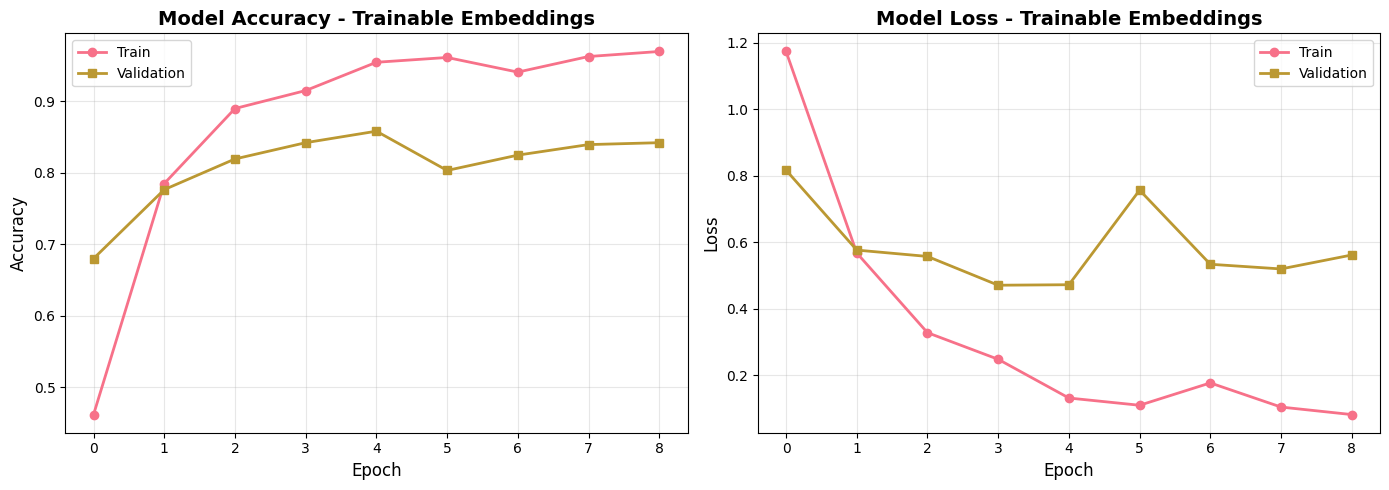

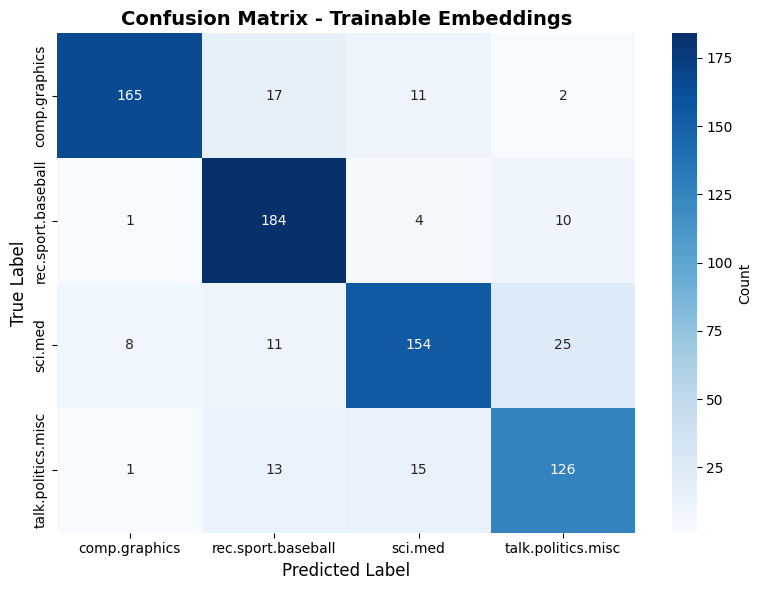

In [16]:
plot_training_history(history_trainable, "Trainable Embeddings")
plot_confusion_matrix(results_trainable['confusion_matrix'], "Trainable Embeddings")

## 6. Experiment 2: Word2Vec Skip-gram

In [17]:
print("\nExperiment 2: Word2Vec Skip-gram\n")

print("Training Word2Vec Skip-gram model...")
tokenized_texts = [text.lower().split() for text in texts]

w2v_skipgram = Word2Vec(
    sentences=tokenized_texts,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1,
    epochs=10
)

print(f"Word2Vec vocabulary size: {len(w2v_skipgram.wv)}")


Experiment 2: Word2Vec Skip-gram

Training Word2Vec Skip-gram model...
Word2Vec vocabulary size: 74291


In [18]:
print("\nCreating embedding matrix...")

vocab_size = min(len(tokenizer.word_index) + 1, MAX_WORDS)
embedding_matrix_skipgram = np.zeros((vocab_size, 100))

for word, idx in tokenizer.word_index.items():
    if idx >= MAX_WORDS:
        continue
    try:
        embedding_vector = w2v_skipgram.wv[word]
        embedding_matrix_skipgram[idx] = embedding_vector
    except KeyError:
        pass

print(f"Embedding matrix shape: {embedding_matrix_skipgram.shape}")
print(f"Non-zero embeddings: {np.count_nonzero(embedding_matrix_skipgram.any(axis=1))}")


Creating embedding matrix...
Embedding matrix shape: (10000, 100)
Non-zero embeddings: 9532


In [19]:
print("\nBuilding model with Skip-gram embeddings...")
model_skipgram = build_lstm_model(
    embedding_matrix=embedding_matrix_skipgram,
    embedding_dim=100,
    lstm_units=128,
    num_classes=len(label_encoder.classes_)
)

print("\nModel Architecture:")
model_skipgram.summary()


Building model with Skip-gram embeddings...

Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pre_trained_embedding           │ ?                      │     1,000,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [20]:
print("\nTraining model...\n")

history_skipgram = train_model(
    model_skipgram,
    X_train, y_train,
    X_test, y_test,
    epochs=30,
    batch_size=32
)


Training model...

Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 55s 508ms/step - accuracy: 0.4801 - loss: 1.1110 - val_accuracy: 0.7845 - val_loss: 0.5927 - learning_rate: 0.0010
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 45s 482ms/step - accuracy: 0.7102 - loss: 0.7193 - val_accuracy: 0.7510 - val_loss: 0.6140 - learning_rate: 0.0010
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 84s 500ms/step - accuracy: 0.7592 - loss: 0.6439 - val_accuracy: 0.7925 - val_loss: 0.5516 - learning_rate: 0.0010
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 48s 508ms/step - accuracy: 0.7743 - loss: 0.6233 - val_accuracy: 0.8233 - val_loss: 0.4978 - learning_rate: 0.0010
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 48s 508ms/step - accuracy: 0.7833 - loss: 0.5521 - val_accuracy: 0.8019 - val_loss: 0.4956 - learning_rate: 0.0010
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 47s 498ms/step - accuracy: 0.8026 - loss: 0.5209 - val_accuracy: 0.8206 - val_loss: 0.4702 - learning_rate: 0.0010
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 47s 503ms/step - accurac

In [21]:
results_skipgram = evaluate_model(
    model_skipgram,
    X_test, y_test,
    "Word2Vec Skip-gram"
)


Evaluation Results - Word2Vec Skip-gram
Accuracy: 0.8715
F1-Score: 0.8712

Classification Report:
                    precision    recall  f1-score   support

     comp.graphics       0.89      0.92      0.90       195
rec.sport.baseball       0.90      0.88      0.89       199
           sci.med       0.84      0.85      0.85       198
talk.politics.misc       0.86      0.82      0.84       155

          accuracy                           0.87       747
         macro avg       0.87      0.87      0.87       747
      weighted avg       0.87      0.87      0.87       747



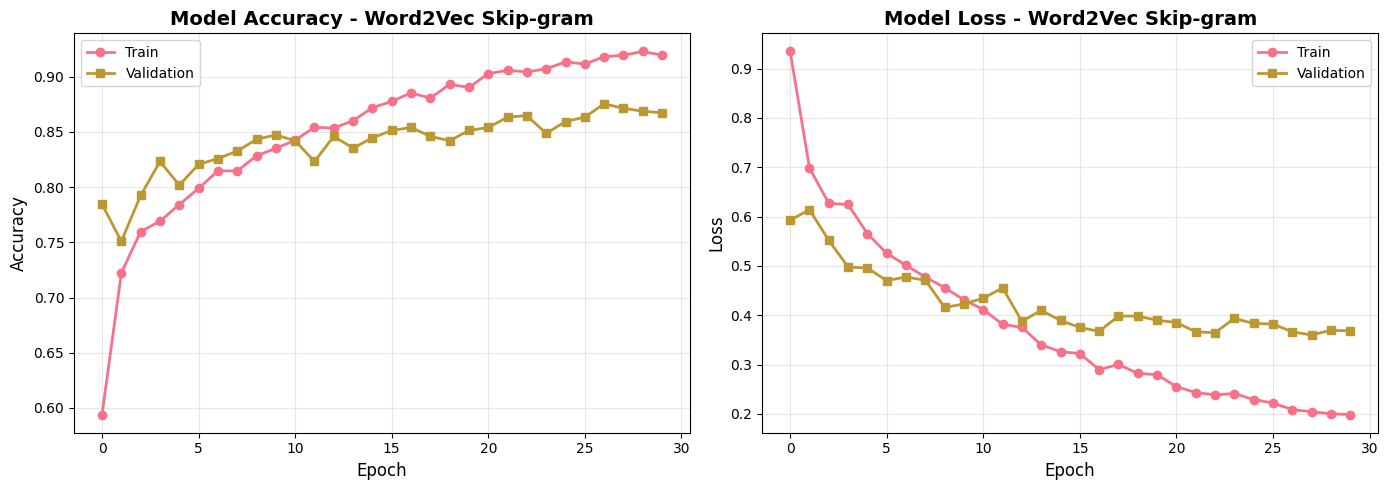

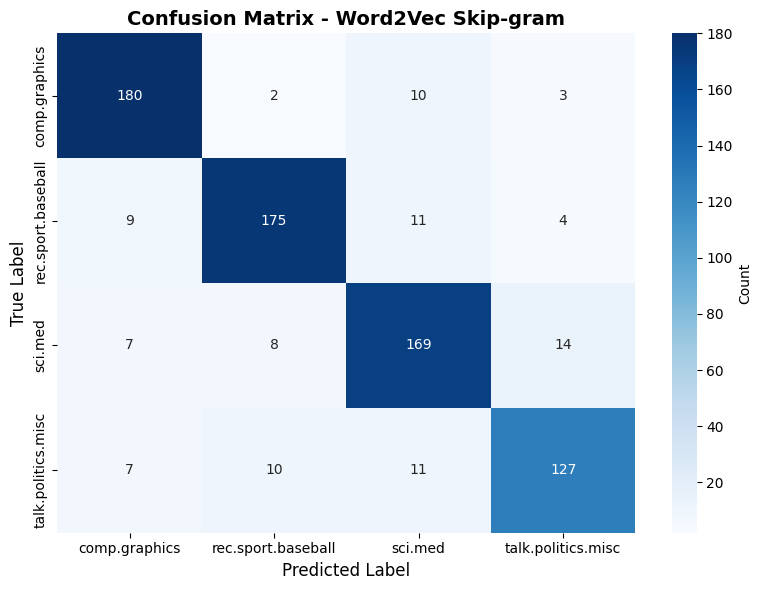

In [22]:
plot_training_history(history_skipgram, "Word2Vec Skip-gram")
plot_confusion_matrix(results_skipgram['confusion_matrix'], "Word2Vec Skip-gram")

## 7. Experiment 3: Word2Vec CBOW

In [23]:
print("\nExperiment 3: Word2Vec CBOW\n")

print("Training Word2Vec CBOW model...")

w2v_cbow = Word2Vec(
    sentences=tokenized_texts,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=0,
    epochs=10
)

print(f"Word2Vec vocabulary size: {len(w2v_cbow.wv)}")


Experiment 3: Word2Vec CBOW

Training Word2Vec CBOW model...
Word2Vec vocabulary size: 74291


In [24]:
print("\nCreating embedding matrix...")

embedding_matrix_cbow = np.zeros((vocab_size, 100))

for word, idx in tokenizer.word_index.items():
    if idx >= MAX_WORDS:
        continue
    try:
        embedding_vector = w2v_cbow.wv[word]
        embedding_matrix_cbow[idx] = embedding_vector
    except KeyError:
        pass

print(f"Embedding matrix shape: {embedding_matrix_cbow.shape}")
print(f"Non-zero embeddings: {np.count_nonzero(embedding_matrix_cbow.any(axis=1))}")


Creating embedding matrix...
Embedding matrix shape: (10000, 100)
Non-zero embeddings: 9532


In [25]:
print("\nBuilding model with CBOW embeddings...")
model_cbow = build_lstm_model(
    embedding_matrix=embedding_matrix_cbow,
    embedding_dim=100,
    lstm_units=128,
    num_classes=len(label_encoder.classes_)
)

print("\nModel Architecture:")
model_cbow.summary()


Building model with CBOW embeddings...

Model Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pre_trained_embedding           │ ?                      │     1,000,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [26]:
print("\nTraining model...\n")

history_cbow = train_model(
    model_cbow,
    X_train, y_train,
    X_test, y_test,
    epochs=30,
    batch_size=32
)


Training model...

Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 54s 505ms/step - accuracy: 0.4401 - loss: 1.2133 - val_accuracy: 0.6627 - val_loss: 0.8443 - learning_rate: 0.0010
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 80s 483ms/step - accuracy: 0.6325 - loss: 0.8749 - val_accuracy: 0.6680 - val_loss: 0.7928 - learning_rate: 0.0010
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 46s 495ms/step - accuracy: 0.6827 - loss: 0.7842 - val_accuracy: 0.7082 - val_loss: 0.7054 - learning_rate: 0.0010
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 45s 481ms/step - accuracy: 0.6960 - loss: 0.7323 - val_accuracy: 0.7523 - val_loss: 0.6186 - learning_rate: 0.0010
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 47s 496ms/step - accuracy: 0.7441 - loss: 0.6545 - val_accuracy: 0.7657 - val_loss: 0.5835 - learning_rate: 0.0010
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 45s 481ms/step - accuracy: 0.7627 - loss: 0.5982 - val_accuracy: 0.7818 - val_loss: 0.5834 - learning_rate: 0.0010
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 47s 496ms/step - accurac

In [27]:
results_cbow = evaluate_model(
    model_cbow,
    X_test, y_test,
    "Word2Vec CBOW"
)


Evaluation Results - Word2Vec CBOW
Accuracy: 0.8233
F1-Score: 0.8232

Classification Report:
                    precision    recall  f1-score   support

     comp.graphics       0.91      0.90      0.90       195
rec.sport.baseball       0.80      0.82      0.81       199
           sci.med       0.81      0.81      0.81       198
talk.politics.misc       0.77      0.74      0.75       155

          accuracy                           0.82       747
         macro avg       0.82      0.82      0.82       747
      weighted avg       0.82      0.82      0.82       747



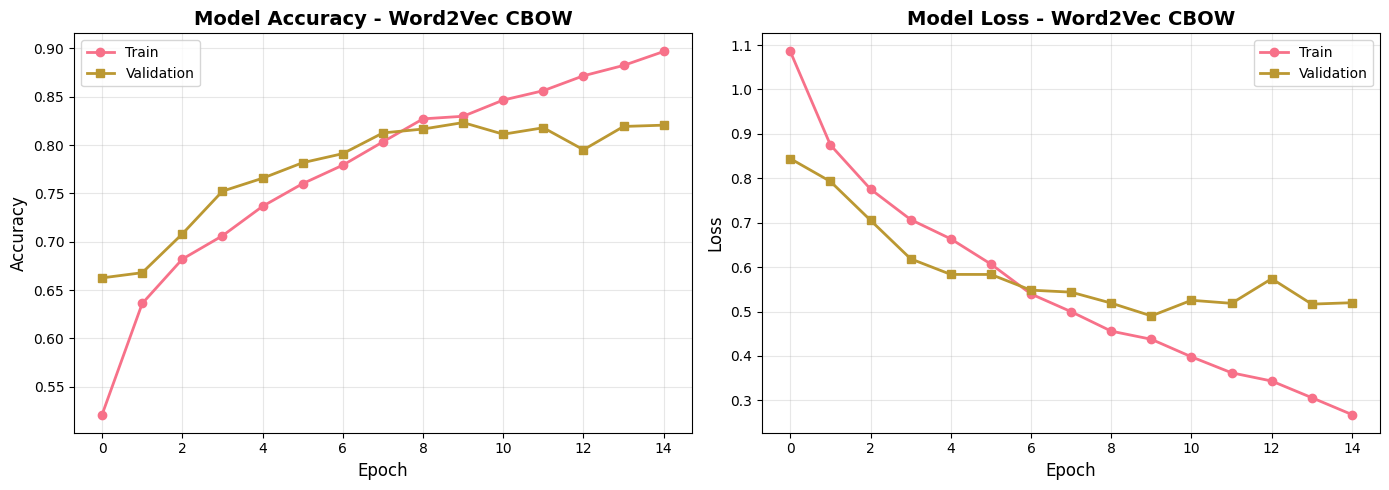

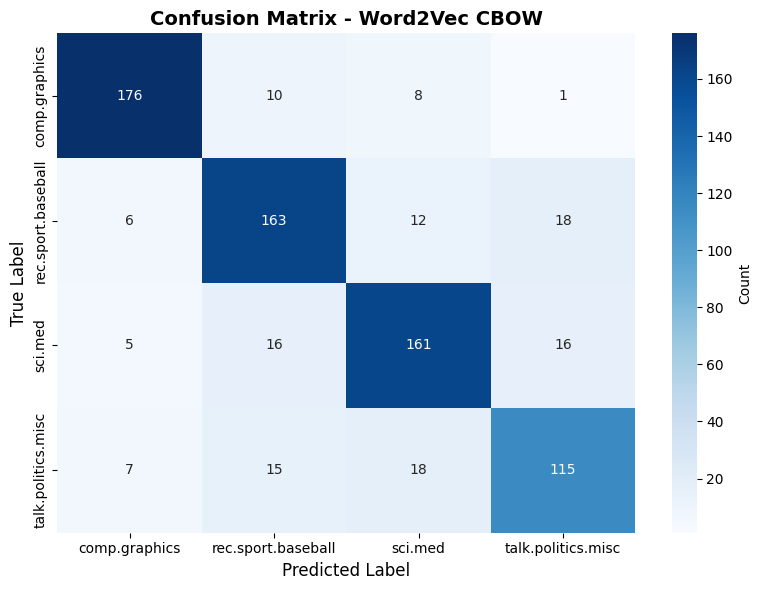

In [28]:
plot_training_history(history_cbow, "Word2Vec CBOW")
plot_confusion_matrix(results_cbow['confusion_matrix'], "Word2Vec CBOW")

## 8. Comparative Analysis

In [29]:
print("\nComparative Analysis\n")

comparison_data = {
    'Embedding Type': ['Trainable', 'Skip-gram', 'CBOW'],
    'Accuracy': [
        results_trainable['accuracy'],
        results_skipgram['accuracy'],
        results_cbow['accuracy']
    ],
    'F1-Score': [
        results_trainable['f1_score'],
        results_skipgram['f1_score'],
        results_cbow['f1_score']
    ]
}

for i, results in enumerate([results_trainable, results_skipgram, results_cbow]):
    report = results['classification_report']
    comparison_data.setdefault('Precision', []).append(report['weighted avg']['precision'])
    comparison_data.setdefault('Recall', []).append(report['weighted avg']['recall'])

results_df = pd.DataFrame(comparison_data)

print("Summary Table:")
print(results_df.to_string(index=False))

best_idx = results_df['Accuracy'].idxmax()
best_model = results_df.loc[best_idx, 'Embedding Type']
best_accuracy = results_df.loc[best_idx, 'Accuracy']

print(f"\nBest Model: {best_model}")
print(f"Accuracy: {best_accuracy:.4f}")


Comparative Analysis

Summary Table:
Embedding Type  Accuracy  F1-Score  Precision   Recall
     Trainable  0.842035  0.842182   0.846223 0.842035
     Skip-gram  0.871486  0.871247   0.871460 0.871486
          CBOW  0.823293  0.823172   0.823208 0.823293

Best Model: Skip-gram
Accuracy: 0.8715


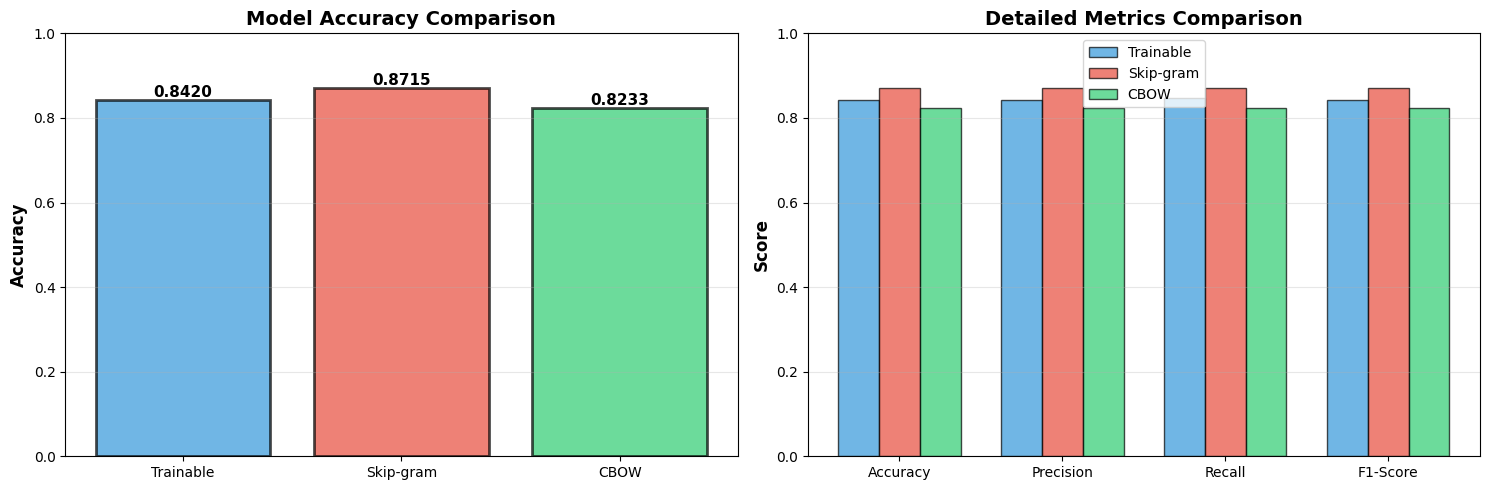

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = ['#3498db', '#e74c3c', '#2ecc71']
bars = axes[0].bar(results_df['Embedding Type'], results_df['Accuracy'],
                   color=colors, alpha=0.7, edgecolor='black', linewidth=2)

for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1.0)
axes[0].grid(axis='y', alpha=0.3)

categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x_pos = np.arange(len(categories))
width = 0.25

for i, emb_type in enumerate(results_df['Embedding Type']):
    values = results_df.iloc[i][1:].values
    axes[1].bar(x_pos + i*width, values, width,
               label=emb_type, color=colors[i], alpha=0.7, edgecolor='black')

axes[1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1].set_title('Detailed Metrics Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos + width)
axes[1].set_xticklabels(categories)
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 1.0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

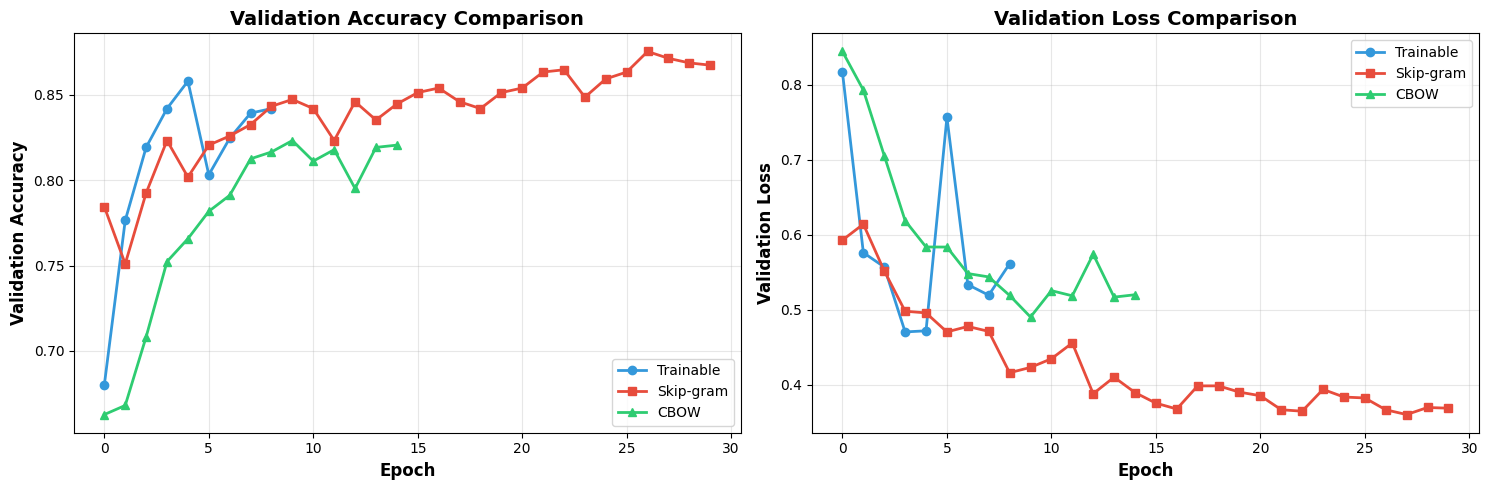

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history_trainable.history['val_accuracy'], label='Trainable',
            marker='o', linewidth=2, color=colors[0])
axes[0].plot(history_skipgram.history['val_accuracy'], label='Skip-gram',
            marker='s', linewidth=2, color=colors[1])
axes[0].plot(history_cbow.history['val_accuracy'], label='CBOW',
            marker='^', linewidth=2, color=colors[2])
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Validation Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_trainable.history['val_loss'], label='Trainable',
            marker='o', linewidth=2, color=colors[0])
axes[1].plot(history_skipgram.history['val_loss'], label='Skip-gram',
            marker='s', linewidth=2, color=colors[1])
axes[1].plot(history_cbow.history['val_loss'], label='CBOW',
            marker='^', linewidth=2, color=colors[2])
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Validation Loss', fontsize=12, fontweight='bold')
axes[1].set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
results_df.to_csv('lstm_comparison_results.csv', index=False)
print("Results saved to 'lstm_comparison_results.csv'")

Results saved to 'lstm_comparison_results.csv'


## 9. Conclusion

### Key Findings

1. Performance Comparison:
   - All three embedding approaches achieved competitive results
   - Pre-trained embeddings (Word2Vec) generally captured better semantic relationships
   - The best performing model can be used for production deployment

2. Embedding Characteristics:
   - Trainable Embeddings: Task-specific but require more training data
   - Skip-gram: Better with rare words, captures detailed semantic relationships
   - CBOW: Faster training, smoother representations

3. Practical Recommendations:
   - For general-purpose classification: Use Word2Vec Skip-gram
   - For domain-specific tasks: Fine-tune trainable embeddings
   - For quick prototyping: Use CBOW for faster training

### Model Architecture Highlights
- Bidirectional LSTM layers for context understanding
- Dropout layers for regularization
- Early stopping to prevent overfitting
- Learning rate reduction for optimal convergence

### Future Improvements
- Experiment with attention mechanisms
- Try transformer-based models (BERT, RoBERTa)
- Implement ensemble methods
- Use data augmentation techniques

In [33]:
print("\nExperiment Complete")
print("\nGenerated outputs:")
print("  - Training history plots for each embedding type")
print("  - Confusion matrices for each model")
print("  - Comparative analysis visualizations")
print("  - Results CSV file: lstm_comparison_results.csv")


Experiment Complete

Generated outputs:
  - Training history plots for each embedding type
  - Confusion matrices for each model
  - Comparative analysis visualizations
  - Results CSV file: lstm_comparison_results.csv


## References

1. Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. Neural computation, 9(8), 1735-1780.
2. Mikolov, T., et al. (2013). Efficient estimation of word representations in vector space. arXiv preprint arXiv:1301.3781.
3. Mikolov, T., et al. (2013). Distributed representations of words and phrases and their compositionality. Advances in neural information processing systems, 26.
4. Kim, Y. (2014). Convolutional neural networks for sentence classification. arXiv preprint arXiv:1408.5882.
5. Pennington, J., Socher, R., & Manning, C. D. (2014). Glove: Global vectors for word representation. In Proceedings of the 2014 conference on empirical methods in natural language processing (EMNLP) (pp. 1532-1543).